# Problem 2: Odbiornik znanego sygnału

### 1. Definicja problemu i detektor (Filtr dopasowany)

W zadaniu weryfikujemy dwie hipotezy dotyczące odebranego sygnału $x(i)$:
* $H_0: x(i) = w(i)$ (brak alarmu, sam szum)
* $H_1: x(i) = A s(i) + w(i)$ (sygnał alarmowy obecny)

Zakładamy, że $w(i)$ to biały szum gaussowski o wariancji $\sigma^2$, a odebrany sygnał traktujemy jako próbę losową.

Optymalną statystyką testową jest korelacja odebranego sygnału ze znanym kodem pseudoszumowym $s(i)$. Odpowiada to działaniu filtru dopasowanego:

$$T = \sum_{i=1}^{N} x(i)s(i)$$

### 2. Teoretyczne rozkłady statystyki testowej

Nasz kod $s(i)$ przyjmuje wartości $\{-1, 1\}$, więc zawsze $s(i)^2 = 1$. Statystyka $T$ jest sumą niezależnych zmiennych normalnych, dlatego sama również ma rozkład normalny. Parametry dla obu hipotez wyliczamy następująco:

**Dla hipotezy $H_0$ (sam szum):**
* Wartość oczekiwana: $\mu_0 = \mathbb{E}\left[\sum w(i)s(i)\right] = 0$
* Wariancja: $\sigma_0^2 = \sum \text{Var}(w(i))s(i)^2 = N\sigma^2$
* Zatem: $T|H_0 \sim \mathcal{N}(0, N\sigma^2)$

**Dla hipotezy $H_1$ (sygnał + szum):**
* Wartość oczekiwana: $\mu_1 = \mathbb{E}\left[\sum (A s(i) + w(i))s(i)\right] = A\sum s(i)^2 + 0 = AN$
* Wariancja pozostaje taka sama: $\sigma_1^2 = N\sigma^2$
* Zatem: $T|H_1 \sim \mathcal{N}(AN, N\sigma^2)$

### 3. Wyznaczanie progu decyzyjnego $\gamma$

Zależy nam na bardzo niskim prawdopodobieństwie fałszywego alarmu ($P_{FA} = \alpha$). Uznajemy, że sygnał został wykryty, jeśli nasza statystyka $T$ przebije próg $\gamma$.

Próg ten wyliczamy z odwrotnej dystrybuanty rozkładu statystyki dla hipotezy zerowej:

$$\gamma = \sqrt{N\sigma^2} \cdot \Phi^{-1}(1 - \alpha)$$

gdzie $\Phi^{-1}$ to odwrotność dystrybuanty standardowego rozkładu normalnego (w kodzie realizowana przez funkcję `norm.isf`).

### 4. Przykładowe działanie algorytmu detekcji

W tej sekcji sprawdzamy w praktyce, jak radzi sobie nasz detektor. Zaczynamy od trudnych warunków: sygnał jest bardzo słaby względem szumu ($A = 0.3$, $\sigma^2 = 1.0$), a my narzucamy bardzo rygorystyczny próg na fałszywe alarmy ($\alpha = 10^{-4}$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
np.random.seed(123)

In [2]:
def detect_statistic(x, s):
    return np.dot(x, s)

def threshold_for_alpha(alpha, N, sigma2):
    return np.sqrt(N * sigma2) * norm.isf(alpha)

def theoretical_pd(A, alpha, N, sigma2):
    gamma = threshold_for_alpha(alpha, N, sigma2)
    return norm.sf((gamma - A * N) / np.sqrt(N * sigma2))

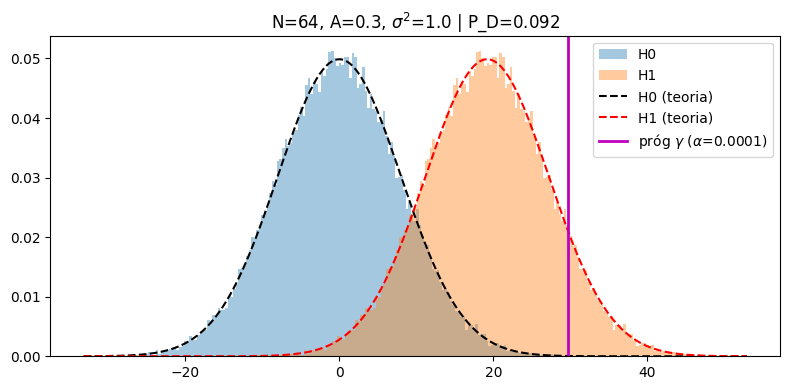

Wyniki eksperymentu:
  gamma = 29.752
  empiryczne P_FA = 0.000160 (docelowe alpha = 0.0001)
  empiryczne P_D  = 0.092460


In [3]:
def run_experiment(N=64, A=0.3, sigma2=1.0, alpha=1e-4, n_times=50000):
    sigma = np.sqrt(sigma2)
    rng = np.random.default_rng(42)
    
    s = np.where(rng.random(N) > 0.5, 1.0, -1.0)
    w = sigma * rng.standard_normal((n_times, N))

    T0 = w.dot(s)
    T1 = (A * s + w).dot(s)

    gamma = threshold_for_alpha(alpha, N, sigma2)
    pfa = np.mean(T0 > gamma)
    pd = np.mean(T1 > gamma)

    mu0, var0 = 0.0, N * sigma2
    mu1, var1 = A * N, N * sigma2

    return {
        'N': N,
        'A': A,
        'sigma2': sigma2,
        'alpha': alpha,
        'n_times': n_times,
        's': s,
        'T0': T0,
        'T1': T1,
        'gamma': gamma,
        'pfa': pfa,
        'pd': pd,
        'mu0': mu0,
        'var0': var0,
        'mu1': mu1,
        'var1': var1,
    }


def plot_experiment(result):
    T0 = result['T0']
    T1 = result['T1']
    gamma = result['gamma']
    pd = result['pd']
    N = result['N']
    A = result['A']
    sigma2 = result['sigma2']
    alpha = result['alpha']
    mu0 = result['mu0']
    var0 = result['var0']
    mu1 = result['mu1']
    var1 = result['var1']

    fig, ax = plt.subplots(figsize=(8,4))
    xs = np.linspace(min(T0.min(), T1.min()), max(T0.max(), T1.max()), 400)
    ax.hist(T0, bins=200, density=True, alpha=0.4, label='H0')
    ax.hist(T1, bins=200, density=True, alpha=0.4, label='H1')
    ax.plot(xs, norm.pdf(xs, mu0, np.sqrt(var0)), 'k--', label='H0 (teoria)')
    ax.plot(xs, norm.pdf(xs, mu1, np.sqrt(var1)), 'r--', label='H1 (teoria)')
    ax.axvline(gamma, color='m', linestyle='-', linewidth=2, label=f'próg $\\gamma$ ($\\alpha$={alpha})')
    ax.set_title(f'N={N}, A={A}, $\\sigma^2$={sigma2} | P_D={pd:.3f}')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print('Wyniki eksperymentu:')
    print(f'  gamma = {gamma:.3f}')
    print(f'  empiryczne P_FA = {result["pfa"]:.6f} (docelowe alpha = {alpha})')
    print(f'  empiryczne P_D  = {pd:.6f}')


result = run_experiment()
plot_experiment(result)

Dla krótkiego sygnału ($N=64$) moc testu ($P_D$) wynosi zaledwie około 9%. Oznacza to, że sygnał w dużej mierze "tonie" w szumie i system przegapia większość alarmów. 

Aby to naprawić - bez zmiany rygorystycznego $\alpha$ wydłużyć kod pseudoszumowy (np. z $N=64$ na $N=512$). Poniżej prezentujemy wyniki symulacji, żeby pokazać, jak wydłużenie $N$ separuje od siebie rozkłady.

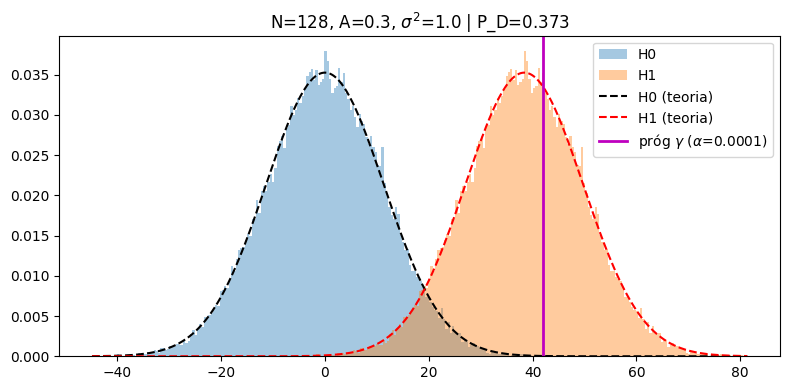

Wyniki eksperymentu:
  gamma = 42.076
  empiryczne P_FA = 0.000100 (docelowe alpha = 0.0001)
  empiryczne P_D  = 0.373060


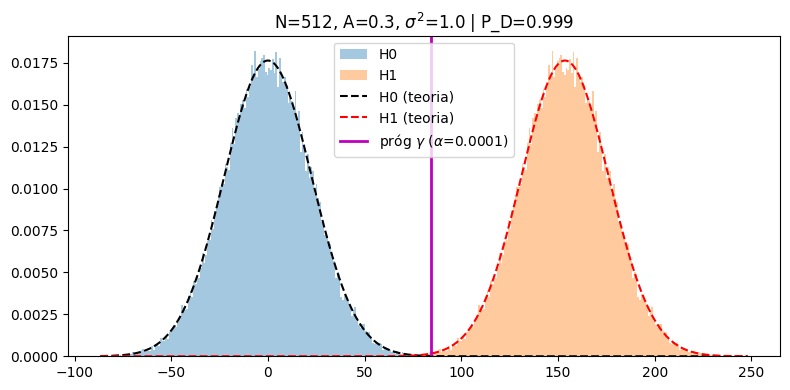

Wyniki eksperymentu:
  gamma = 84.152
  empiryczne P_FA = 0.000040 (docelowe alpha = 0.0001)
  empiryczne P_D  = 0.998980


In [4]:
result_128 = run_experiment(N=128)
plot_experiment(result_128)

result_512 = run_experiment(N=512)
plot_experiment(result_512)

#### Wnioski z symulacji
Jak widać na powyższych wykresach, empiryczne histogramy praktycznie idealnie pokrywają się z teoretycznymi krzywymi rozkładu normalnego. Zwiększenie długości kodu $N$ drastycznie rozsuwa oba rozkłady od siebie, co pozwala na bezbłędną detekcję ($P_D$ bliskie 100%) nawet tak słabego sygnału ($A=0.3$).

### 5. Analiza mocy testu w zależności od parametrów

W tej sekcji sprawdzamy analitycznie, jak prawdopodobieństwo poprawnej detekcji ($P_D$) reaguje na zmianę poszczególnych parametrów systemu: amplitudy sygnału ($A$), długości kodu ($N$) oraz wariancji szumu ($\sigma^2$). Wartością bazową pozostaje $\alpha = 10^{-4}$.

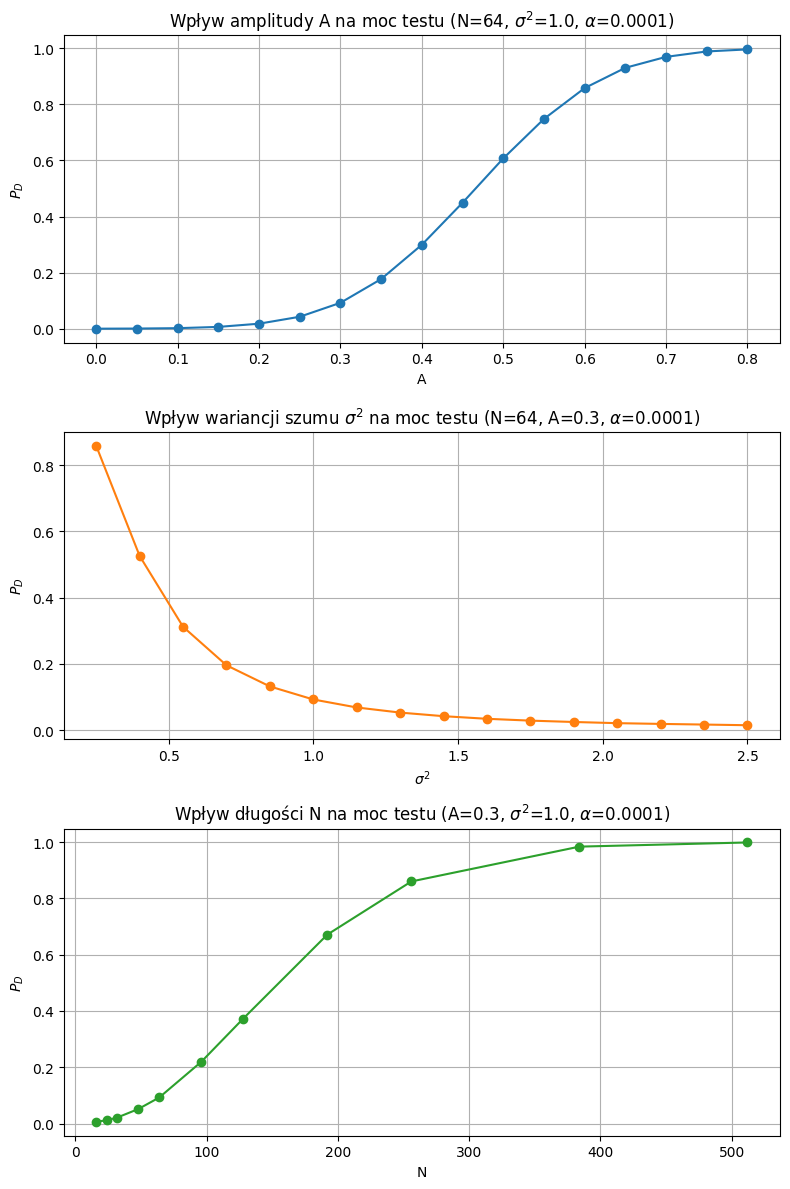

In [6]:
def plot_power_curve(ax, x_values, pd_values, title, xlabel, color='tab:blue'):
    ax.plot(x_values, pd_values, marker='o', color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'$P_D$')
    ax.grid(True)

base_N = 64
base_A = 0.3
base_sigma2 = 1.0
base_alpha = 1e-4
base_n_times = 50000

A_values = np.linspace(0.0, 0.8, 17)
sigma2_values = np.linspace(0.25, 2.5, 16)
N_values = np.array([16, 24, 32, 48, 64, 96, 128, 192, 256, 384, 512])

pd_vs_A = []
for A in A_values:
    result = run_experiment(N=base_N, A=A, sigma2=base_sigma2, alpha=base_alpha, n_times=base_n_times)
    pd_vs_A.append(result['pd'])

pd_vs_sigma2 = []
for sigma2 in sigma2_values:
    result = run_experiment(N=base_N, A=base_A, sigma2=sigma2, alpha=base_alpha, n_times=base_n_times)
    pd_vs_sigma2.append(result['pd'])

pd_vs_N = []
for N in N_values:
    result = run_experiment(N=N, A=base_A, sigma2=base_sigma2, alpha=base_alpha, n_times=base_n_times)
    pd_vs_N.append(result['pd'])

fig, axes = plt.subplots(3, 1, figsize=(8, 12))
plot_power_curve(
    axes[0],
    A_values,
    pd_vs_A,
    f'Wpływ amplitudy A na moc testu (N={base_N}, $\\sigma^2$={base_sigma2}, $\\alpha$={base_alpha})',
    'A',
    color='tab:blue',
)
plot_power_curve(
    axes[1],
    sigma2_values,
    pd_vs_sigma2,
    f'Wpływ wariancji szumu $\\sigma^2$ na moc testu (N={base_N}, A={base_A}, $\\alpha$={base_alpha})',
    '$\\sigma^2$',
    color='tab:orange',
)
plot_power_curve(
    axes[2],
    N_values,
    pd_vs_N,
    f'Wpływ długości N na moc testu (A={base_A}, $\\sigma^2$={base_sigma2}, $\\alpha$={base_alpha})',
    'N',
    color='tab:green',
)
plt.tight_layout()
plt.show()

#### Wnioski z analizy parametrów
1. **Wpływ amplitudy ($A$):** Wraz ze wzrostem amplitudy, wartość oczekiwana przy hipotezie $H_1$ ($AN$) oddala się od zera. Przy stałym szumie daje to niemal liniowy przyrost skuteczności detekcji (aż do wypłaszczenia przy $P_D \approx 1$).
2. **Wpływ wariancji szumu ($\sigma^2$):** Wzrost wariancji szumu "rozmywa" oba rozkłady, powodując, że zaczynają się one mocno na siebie nakładać. Konsekwencją jest gwałtowny spadek mocy testu.
3. **Wpływ długości sygnału ($N$):** Kluczowy parametr dla słabych sygnałów (jak z resztą pokazaliśmy powyżej). Dłuższy kod to większa różnica między średnimi rozkładów, co pozwala "wyciągnąć" sygnał z szumu.
4. **Przypadek silnego zaszumienia ($A \ll \sigma^2$):** To sytuacja, w której amplituda sygnału jest drastycznie mniejsza od poziomu szumu. Z naszych analiz jasno wynika, że jedynym ratunkiem na podbicie skuteczności detekcji w takich warunkach (bez zmieniania rygorystycznego progu $\alpha$) jest mocne wydłużenie kodu $N$. Zwiększa to zysk przetwarzania i pozwala skutecznie "wyciągnąć" nawet bardzo słaby sygnał spod szumu.

### 6. Koncepcja systemu telekomunikacyjnego

Wysłanie sygnału alarmowego to w praktyce przesłanie 1 bita informacji (jest alarm / nie ma alarmu). 

* **Jak ustawić próg w standardowym systemie?** W telekomunikacji rzadko zależy nam tylko na ucinaniu fałszywych alarmów za wszelką cenę. Częściej optymalizuje się system pod kątem zminimalizowania błędów transmisji. Zakładając, że w przesyłanych wiadomościach 1 i 0 są tak samo częste, próg decyzyjny powinien leżeć dokładnie pośrodku między średnimi obu rozkładów, czyli $\gamma = \frac{AN}{2}$.
* **Czy da się wysyłać wiele bitów na raz?** Tak. Wystarczy każdemu bitowi przypisać inny, unikalny kod (kody ortogonalne, które się ze sobą nie "gryzą"). Wszystkie tak zakodowane bity można wysłać jednocześnie w tym samym kanale jako jedną mieszankę sygnałów. Odbiornik, znając te kody, stosując zestaw filtrów - rozpląta tą mieszankę i odczyta każdy bit z osobna.